# Pose Estimation — Evaluation

YOLO11-pose を中心に、pose estimation 実験の結果を横断比較する notebook。

- `experiment_summary.json` と `best_test_results/summary.json` を読む
- `predictions.csv` があれば予測分布と可視化を見る
- 最後に random 1 枚を選び、GT と推論 keypoint を画像上で確認する


In [15]:
from __future__ import annotations

import ast
import json
import random
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from PIL import Image

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)

CHECKPOINT_ROOT = Path("/workspace/checkpoints/pose_estimation")
VAL_ANN_PATH = Path("/workspace/data/coco_pose/annotations/person_keypoints_val2017.json")
VAL_IMAGE_ROOT = Path("/workspace/data/coco_pose/images/val2017")

COCO_KEYPOINT_NAMES = [
    "nose", "left_eye", "right_eye", "left_ear", "right_ear",
    "left_shoulder", "right_shoulder", "left_elbow", "right_elbow",
    "left_wrist", "right_wrist", "left_hip", "right_hip",
    "left_knee", "right_knee", "left_ankle", "right_ankle",
]
COCO_SKELETON = [
    (15, 13), (13, 11), (16, 14), (14, 12),
    (11, 12), (5, 11), (6, 12), (5, 6),
    (5, 7), (6, 8), (7, 9), (8, 10),
    (1, 2), (0, 1), (0, 2), (1, 3), (2, 4),
    (3, 5), (4, 6),
]


In [16]:
def load_json(path: Path):
    return json.loads(path.read_text()) if path.exists() else {}


def load_dataframe(path: Path) -> pd.DataFrame:
    return pd.read_csv(path) if path.exists() else pd.DataFrame()


def discover_experiment_dirs() -> list[Path]:
    return sorted(
        experiment_dir
        for experiment_dir in CHECKPOINT_ROOT.glob("*/*")
        if (experiment_dir / "experiment_summary.json").exists()
    )


def load_experiment_artifact(experiment_dir: Path) -> dict[str, object]:
    experiment_summary = load_json(experiment_dir / "experiment_summary.json")
    test_summary = load_json(experiment_dir / "best_test_results" / "summary.json")
    predictions_df = load_dataframe(experiment_dir / "best_test_results" / "predictions.csv")
    grid_df = load_dataframe(experiment_dir / "grid" / "tuning_results.csv")
    return {
        "experiment_dir": experiment_dir,
        "task_model_name": experiment_dir.parent.name,
        "experiment_name": experiment_dir.name,
        "experiment_summary": experiment_summary,
        "test_summary": test_summary,
        "predictions_df": predictions_df,
        "grid_df": grid_df,
        "has_predictions": len(predictions_df) > 0,
    }


def parse_keypoints(value) -> list[float]:
    if isinstance(value, list):
        return value
    if isinstance(value, str):
        try:
            parsed = ast.literal_eval(value)
            return parsed if isinstance(parsed, list) else []
        except Exception:
            return []
    return []


def draw_pose(ax, image: np.ndarray, keypoints_flat: list[float], bbox=None, *, title: str, color: str = "tab:red", min_score: float = 0.2) -> None:
    ax.imshow(image)
    ax.set_title(title)
    ax.axis("off")

    if bbox is not None:
        x, y, w, h = [float(v) for v in bbox]
        rect = patches.Rectangle((x, y), w, h, linewidth=2, edgecolor=color, facecolor="none")
        ax.add_patch(rect)

    if not keypoints_flat:
        return

    xs, ys, vs = [], [], []
    for i in range(0, len(keypoints_flat), 3):
        x, y, v = keypoints_flat[i:i+3]
        xs.append(float(x))
        ys.append(float(y))
        vs.append(float(v))

    for start, end in COCO_SKELETON:
        i, j = start, end
        if i < len(vs) and j < len(vs) and vs[i] > min_score and vs[j] > min_score:
            ax.plot([xs[i], xs[j]], [ys[i], ys[j]], color=color, linewidth=2, alpha=0.85)

    for x, y, v in zip(xs, ys, vs):
        if v > min_score:
            ax.scatter([x], [y], s=20, c=color)


experiment_dirs = discover_experiment_dirs()
if not experiment_dirs:
    raise FileNotFoundError("No pose estimation experiment_summary.json found under /workspace/checkpoints/pose_estimation")

artifacts = [load_experiment_artifact(experiment_dir) for experiment_dir in experiment_dirs]
len(artifacts)


2

## 1. Overview — 実験一覧と主要指標


,task_model_name,experiment_name,mode,best_source,best_valid_ap,best_valid_ap50,test_ap,test_ap50,test_ap75,test_ap_medium,test_ap_large,test_ar,has_predictions,n_predictions
1,yolo11_pose,yolo11_pose_coco_smoke,none,train,0.350329,0.498968,0.569170,0.844793,0.641469,0.405383,0.740287,0.627027,True,939
0,yolo11_pose,yolo11_pose_coco,grid,grid,0.241845,0.420885,0.427268,0.750354,0.441248,0.389392,0.500546,0.511020,True,180378


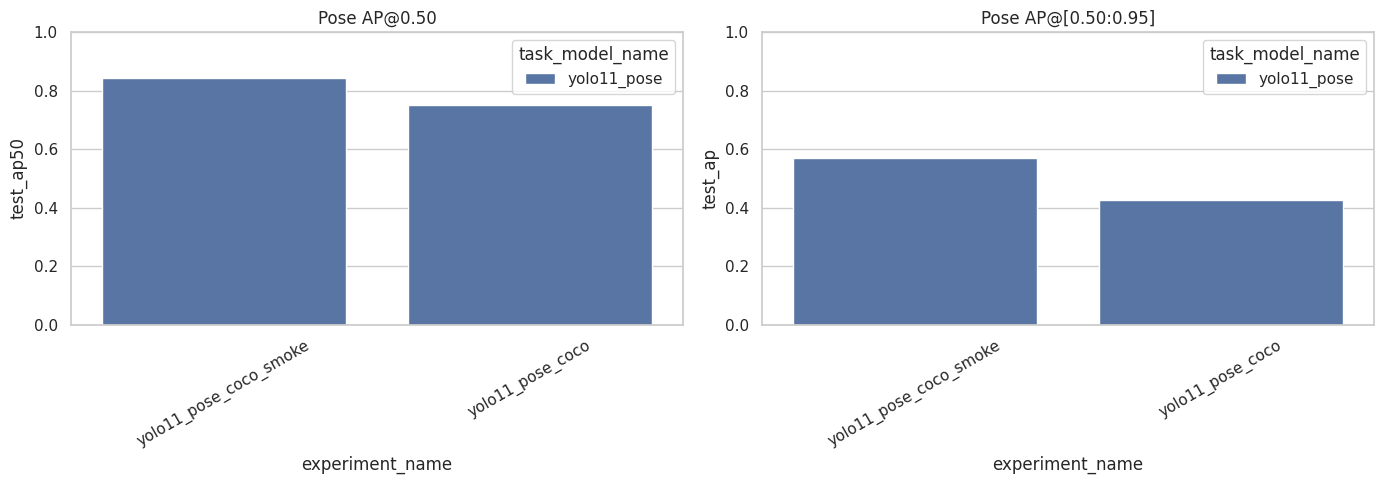

In [17]:
rows = []
for artifact in artifacts:
    experiment_summary = artifact["experiment_summary"]
    test_summary = artifact["test_summary"]
    rows.append({
        "task_model_name": artifact["task_model_name"],
        "experiment_name": artifact["experiment_name"],
        "mode": experiment_summary.get("mode"),
        "best_source": experiment_summary.get("best_source"),
        "best_valid_ap": experiment_summary.get("best_valid_ap"),
        "best_valid_ap50": experiment_summary.get("best_valid_ap50"),
        "test_ap": test_summary.get("ap", experiment_summary.get("test_ap")),
        "test_ap50": test_summary.get("ap50", experiment_summary.get("test_ap50")),
        "test_ap75": test_summary.get("ap75"),
        "test_ap_medium": test_summary.get("ap_medium"),
        "test_ap_large": test_summary.get("ap_large"),
        "test_ar": test_summary.get("ar"),
        "has_predictions": artifact["has_predictions"],
        "n_predictions": len(artifact["predictions_df"]),
    })

overview_df = pd.DataFrame(rows).sort_values(["test_ap50", "test_ap"], ascending=False, na_position="last")
display(overview_df)

plot_df = overview_df.dropna(subset=["test_ap50", "test_ap"]) if len(overview_df) else pd.DataFrame()
if len(plot_df):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    sns.barplot(data=plot_df, x="experiment_name", y="test_ap50", hue="task_model_name", ax=axes[0])
    axes[0].set_title("Pose AP@0.50")
    axes[0].set_ylim(0, 1)
    axes[0].tick_params(axis="x", rotation=30)

    sns.barplot(data=plot_df, x="experiment_name", y="test_ap", hue="task_model_name", ax=axes[1])
    axes[1].set_title("Pose AP@[0.50:0.95]")
    axes[1].set_ylim(0, 1)
    axes[1].tick_params(axis="x", rotation=30)
    plt.tight_layout()
else:
    print("No completed pose test summaries found.")


## 2. Scale 別 AP (medium / large)


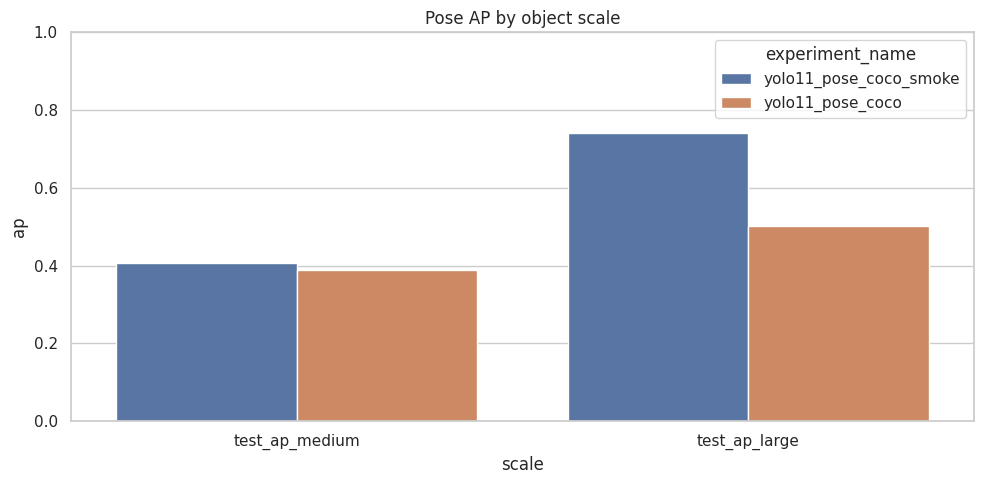

In [18]:
scale_df = overview_df[["experiment_name", "task_model_name", "test_ap_medium", "test_ap_large"]].dropna()
if len(scale_df):
    melted = scale_df.melt(
        id_vars=["experiment_name", "task_model_name"],
        value_vars=["test_ap_medium", "test_ap_large"],
        var_name="scale",
        value_name="ap",
    )
    plt.figure(figsize=(10, 5))
    sns.barplot(data=melted, x="scale", y="ap", hue="experiment_name")
    plt.title("Pose AP by object scale")
    plt.ylim(0, 1)
    plt.tight_layout()
else:
    print("No scale-specific pose AP found.")


## 3. Prediction 分布


,model_experiment,mean_n_pred,mean_score
0,yolo11_pose / yolo11_pose_coco,40.507074,0.051676
1,yolo11_pose / yolo11_pose_coco_smoke,29.343750,0.151904


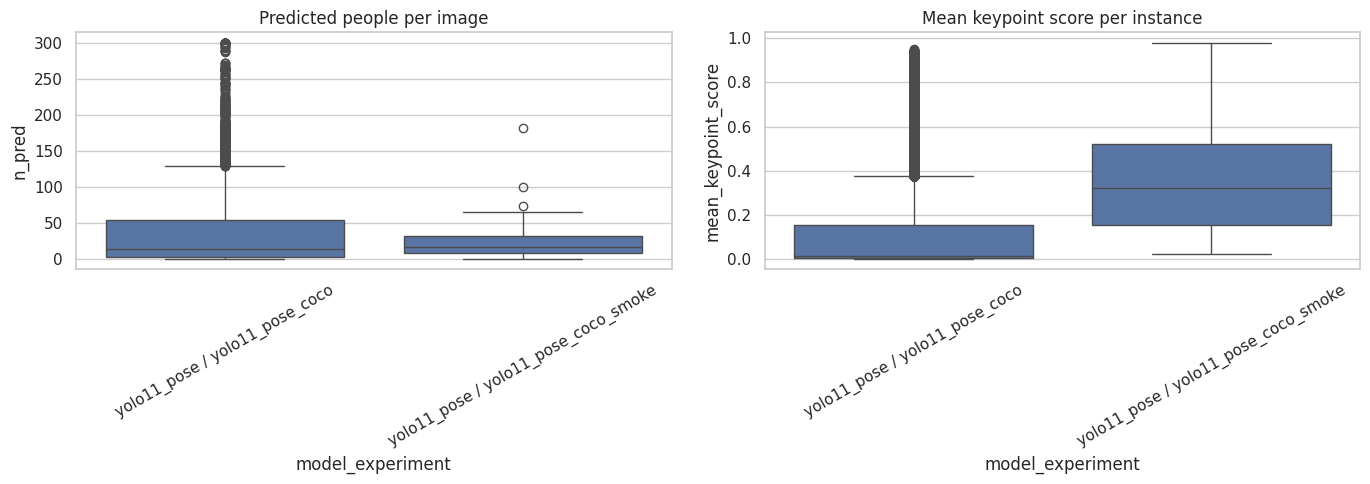

In [19]:
prediction_frames = []
for artifact in artifacts:
    predictions_df = artifact["predictions_df"]
    if len(predictions_df) == 0:
        continue
    temp_df = predictions_df.copy()
    temp_df["task_model_name"] = artifact["task_model_name"]
    temp_df["experiment_name"] = artifact["experiment_name"]
    temp_df["model_experiment"] = temp_df["task_model_name"] + " / " + temp_df["experiment_name"]
    prediction_frames.append(temp_df)

all_predictions_df = pd.concat(prediction_frames, ignore_index=True) if prediction_frames else pd.DataFrame()
if len(all_predictions_df):
    image_level_counts = (
        all_predictions_df.groupby(["model_experiment", "image_id"], as_index=False)
        .agg(n_pred=("instance_id", "count"), mean_score=("score", "mean"))
    )
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    sns.boxplot(data=image_level_counts, x="model_experiment", y="n_pred", ax=axes[0])
    axes[0].set_title("Predicted people per image")
    axes[0].tick_params(axis="x", rotation=30)

    sns.boxplot(data=all_predictions_df, x="model_experiment", y="mean_keypoint_score", ax=axes[1])
    axes[1].set_title("Mean keypoint score per instance")
    axes[1].tick_params(axis="x", rotation=30)
    plt.tight_layout()

    display(image_level_counts.groupby("model_experiment").agg(mean_n_pred=("n_pred", "mean"), mean_score=("mean_score", "mean")).reset_index())
else:
    print("predictions.csv not found for any pose experiment.")


## 4. Grid Tuning 結果


In [20]:
grid_frames = []
for artifact in artifacts:
    grid_df = artifact["grid_df"]
    if len(grid_df) == 0:
        continue
    temp_df = grid_df.copy()
    temp_df["task_model_name"] = artifact["task_model_name"]
    temp_df["experiment_name"] = artifact["experiment_name"]
    grid_frames.append(temp_df)

grid_all_df = pd.concat(grid_frames, ignore_index=True) if grid_frames else pd.DataFrame()
if len(grid_all_df):
    display(grid_all_df.sort_values("best_valid_ap50", ascending=False))
else:
    print("Grid tuning results not found.")


Grid tuning results not found.


## 5. Random sample visualization — GT と推論 keypoint を画像上で確認する

`predictions.csv` から random 1 枚を選び、GT と各実験の推論を比較する。
同一 image_id に複数 person がいる場合は、score 最大の 1 instance を描画する。


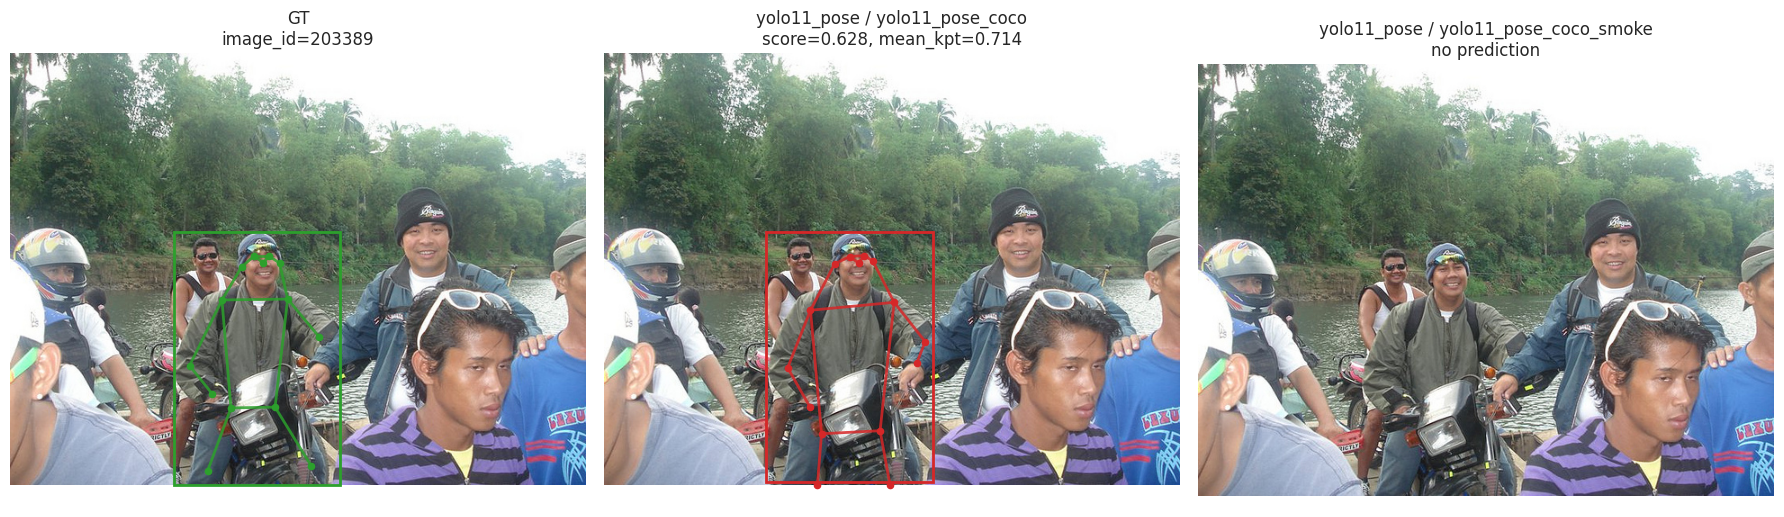

In [28]:
ann = load_json(VAL_ANN_PATH)
image_info_by_id = {int(img["id"]): img for img in ann.get("images", [])}
gt_annotations_by_image: dict[int, list[dict]] = {}
for obj in ann.get("annotations", []):
    if int(obj.get("iscrowd", 0)):
        continue
    if int(obj.get("num_keypoints", 0)) <= 0:
        continue
    gt_annotations_by_image.setdefault(int(obj["image_id"]), []).append(obj)

vis_artifacts = [artifact for artifact in artifacts if len(artifact["predictions_df"]) > 0]
candidate_image_ids = set()
for artifact in vis_artifacts:
    candidate_image_ids.update(artifact["predictions_df"]["image_id"].astype(int).unique().tolist())

if not candidate_image_ids:
    print("No predictions found for visualization.")
else:
    selected_image_id = random.choice(sorted(candidate_image_ids))
    image_info = image_info_by_id[selected_image_id]
    image_path = VAL_IMAGE_ROOT / image_info["file_name"]
    base_image = np.array(Image.open(image_path).convert("RGB"))

    gt_candidates = sorted(
        gt_annotations_by_image.get(selected_image_id, []),
        key=lambda ann: int(ann.get("num_keypoints", 0)),
        reverse=True,
    )
    gt_ann = gt_candidates[0] if gt_candidates else None

    n_cols = len(vis_artifacts) + 1
    fig, axes = plt.subplots(1, n_cols, figsize=(6 * n_cols, 8))
    if n_cols == 1:
        axes = [axes]

    gt_title = f"GT\nimage_id={selected_image_id}"
    if gt_ann is not None:
        draw_pose(axes[0], base_image, gt_ann.get("keypoints", []), bbox=gt_ann.get("bbox"), title=gt_title, color="tab:green", min_score=0.1)
    else:
        axes[0].imshow(base_image)
        axes[0].set_title(gt_title + "\nno GT keypoints")
        axes[0].axis("off")

    for ax, artifact in zip(axes[1:], vis_artifacts):
        pred_df = artifact["predictions_df"].copy()
        pred_df = pred_df[pred_df["image_id"].astype(int) == selected_image_id]
        if len(pred_df):
            pred_df = pred_df.sort_values("score", ascending=False).reset_index(drop=True)
            best_row = pred_df.iloc[0]
            keypoints = parse_keypoints(best_row["keypoints"])
            bbox = [best_row["bbox_x"], best_row["bbox_y"], best_row["bbox_w"], best_row["bbox_h"]]
            title = (
                f"{artifact['task_model_name']} / {artifact['experiment_name']}\n"
                f"score={float(best_row['score']):.3f}, mean_kpt={float(best_row['mean_keypoint_score']):.3f}"
            )
            draw_pose(ax, base_image, keypoints, bbox=bbox, title=title, color="tab:red", min_score=0.2)
        else:
            ax.imshow(base_image)
            ax.set_title(f"{artifact['task_model_name']} / {artifact['experiment_name']}\nno prediction")
            ax.axis("off")

    plt.tight_layout()
    plt.show()


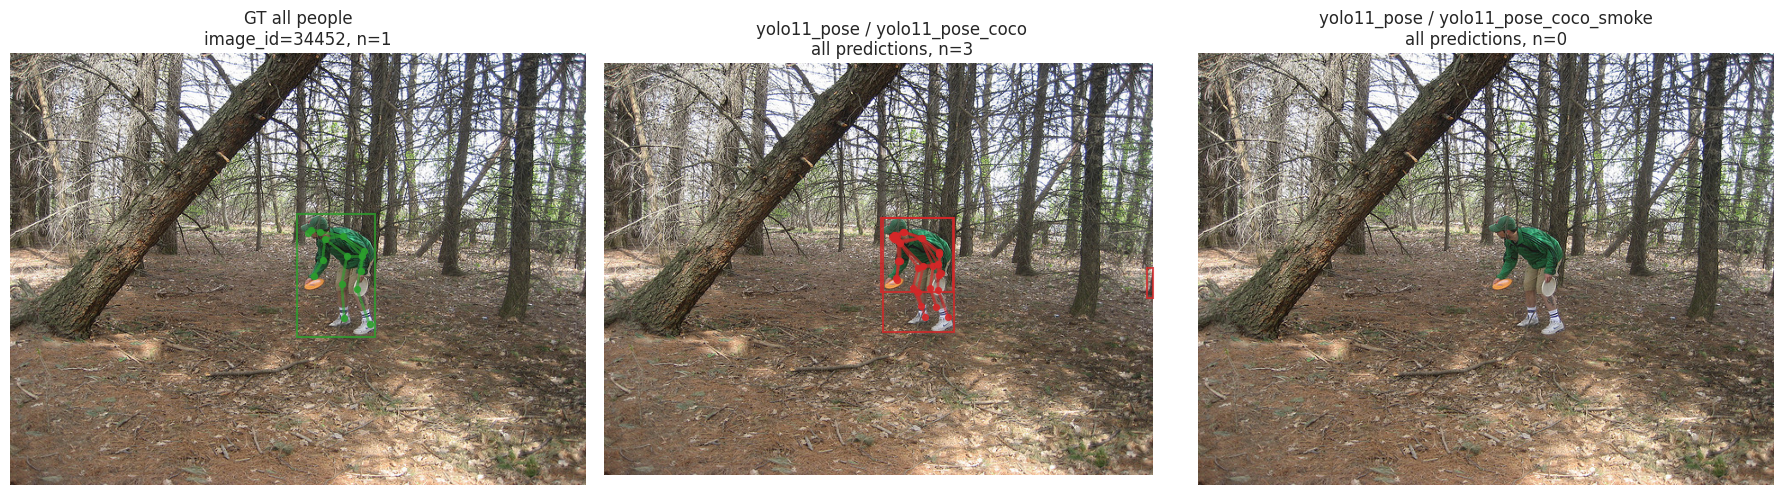

In [46]:
# 6. Random sample visualization — all people in GT / prediction
# 既存セルは 1 人だけを描く版。このセルは同一 image_id の全 instance を重ねて見る版。

if not candidate_image_ids:
    print("No predictions found for visualization.")
else:
    selected_image_id_all = random.choice(sorted(candidate_image_ids))
    image_info = image_info_by_id[selected_image_id_all]
    image_path = VAL_IMAGE_ROOT / image_info["file_name"]
    base_image = np.array(Image.open(image_path).convert("RGB"))

    def draw_pose_instances(ax, image: np.ndarray, instances: list[dict], *, title: str, color: str, min_score: float = 0.2) -> None:
        ax.imshow(image)
        ax.set_title(title)
        ax.axis("off")
        for instance in instances:
            keypoints_flat = instance.get("keypoints", [])
            bbox = instance.get("bbox")
            if bbox is not None:
                x, y, w, h = [float(v) for v in bbox]
                rect = patches.Rectangle((x, y), w, h, linewidth=1.5, edgecolor=color, facecolor="none", alpha=0.8)
                ax.add_patch(rect)

            xs, ys, vs = [], [], []
            for i in range(0, len(keypoints_flat), 3):
                x, y, v = keypoints_flat[i:i+3]
                xs.append(float(x))
                ys.append(float(y))
                vs.append(float(v))

            for start, end in COCO_SKELETON:
                i, j = start, end
                if i < len(vs) and j < len(vs) and vs[i] > min_score and vs[j] > min_score:
                    ax.plot([xs[i], xs[j]], [ys[i], ys[j]], color=color, linewidth=2, alpha=0.6)

            for x, y, v in zip(xs, ys, vs):
                if v > min_score:
                    ax.scatter([x], [y], s=18, c=color, alpha=0.85)

    gt_instances_all = [
        {"keypoints": ann.get("keypoints", []), "bbox": ann.get("bbox")}
        for ann in gt_annotations_by_image.get(selected_image_id_all, [])
    ]

    n_cols = len(vis_artifacts) + 1
    fig, axes = plt.subplots(1, n_cols, figsize=(6 * n_cols, 8))
    if n_cols == 1:
        axes = [axes]

    draw_pose_instances(
        axes[0],
        base_image,
        gt_instances_all,
        title=f"GT all people\nimage_id={selected_image_id_all}, n={len(gt_instances_all)}",
        color="tab:green",
        min_score=0.1,
    )

    for ax, artifact in zip(axes[1:], vis_artifacts):
        pred_df = artifact["predictions_df"].copy()
        pred_df = pred_df[pred_df["image_id"].astype(int) == selected_image_id_all]
        pred_instances_all = []
        if len(pred_df):
            pred_df = pred_df.sort_values("score", ascending=False).reset_index(drop=True)
            for row in pred_df.itertuples(index=False):
                pred_instances_all.append({
                    "keypoints": parse_keypoints(row.keypoints),
                    "bbox": [row.bbox_x, row.bbox_y, row.bbox_w, row.bbox_h],
                })

        draw_pose_instances(
            ax,
            base_image,
            pred_instances_all,
            title=(
                f"{artifact['task_model_name']} / {artifact['experiment_name']}\n"
                f"all predictions, n={len(pred_instances_all)}"
            ),
            color="tab:red",
            min_score=0.2,
        )

    plt.tight_layout()
    plt.show()
